In [1]:
%load_ext autoreload
%autoreload 2

import json
import warnings 
from pathlib import Path
from collections import defaultdict
from typing import Optional, List
from functools import partial

from tqdm import tqdm

import jax
import jax.numpy as jnp
from jax import jit, hessian, grad, jacrev, jacfwd
jax.config.update("jax_enable_x64", True)

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from source.visuals import PARAMS, plot_mtx, plot_mtx_list

from source.model_functionality import (
    get_fw_hadamard_mtx,
    get_ww_hadamard_mtx,
    predict_score,
    prepare_system,
    check_zero_cols,
    init_weights,
    hess_full,
)
from source.matrix_operations import (
    khatri_rao_row, 
    block_diag, 
    vec2ten3, 
    ten3tovec, 
    factors2vec,
)
from source.prob_functions import (
    update_gamma_w, 
    update_beta_e, 
    w_sample,
)
from source.var_model import cov_estimation, low_rank_cov_estimation, jacob_cpd, gn_hess_estimation, var_cpd_als

from source.evaluation import rmse, nll, l2_gb_loss, norm_frob
from source.data_functions import load_transform_data, get_batches, scale_data
from source.features import PPFeature, PPNFeature, RBFFeature, FFeature, prepare_fmap
from source.general_functions import update_results_dict, extend_results_dict, create_dir_if_not_exists, query_df, check_nan
from source.optimization import adam_update, gd_update, full_grid
from source.optimizer import cpd_solution, als_cpd, adam_cpd

import os
import imageio
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme()

DATA_DIR = Path('./data')

In [2]:
def generate_random_x(n_samples, d_dim, min_v=-4, max_v=4, seed=None):
    return np.random.RandomState(seed).uniform(min_v, max_v, (n_samples, d_dim))

def generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, std_err=1.0, min_v=-4, max_v=4, seed=None):
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed)
    x = jnp.array(scale_data(x, jnp.empty_like(x), [1], [1], True, False, 'std')[0])
    fmap, dtype = prepare_fmap(fmap_tuple, m_order, False)
    w_ten, kd = init_weights(m_order, rank, d_dim, q_base=None, init_type=None, seed=seed, dtype=dtype)
    y_true = predict_score(x, kd, w_ten, fmap)
    err = std_err*np.random.RandomState(seed).randn(n_samples)
    y = y_true + err
    return x, y, y_true, err, fmap, w_ten, kd

def get_design_mtx(x, fmap):
    design_mtx = fmap(x[:, 0], None)
    for k in range(1, x.shape[1]):
        design_mtx = khatri_rao_row(fmap(x[:, k], None), design_mtx)
    return design_mtx

def grad_cpd(w_ten, kd, x, y, fmap, gamma_w, beta_e):
    dw = jnp.empty_like(w_ten, dtype=w_ten.dtype)
    fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
    for ind, wk in enumerate(w_ten):
        k, q = divmod(ind, kd) # q starts from zero -> for fmap
        phi_k = fmap(x[:, k], q)
        phi_w = phi_k.dot(wk)
        fw_hadamard /= (phi_w + 1e-14)
        fk = khatri_rao_row(fw_hadamard, phi_k)
        fw_hadamard *= phi_w
        wk_vec = wk.reshape(-1, order='F')
        res = beta_e*fk.T.dot(fk.dot(wk_vec) - y) + gamma_w*wk_vec
        dw = dw.at[ind].set(res.reshape(wk.shape, order='F'))
    return dw

def predict_score_vec(x, kd, w_vec, fmap, D, I, R):
    w_ten = vec2ten3(w_vec, D, I, R)
    score = jnp.ones((x.shape[0], w_ten.shape[-1]), dtype=w_ten.dtype)
    for ind, wk in enumerate(w_ten):
        k, q = divmod(ind, kd) # q starts from zero -> for fmap
        score *= fmap(x[:, k], q).dot(wk)
    return jnp.real(jnp.sum(score, 1))

def zero_diagonal_blocks(matrix, block_size):
    n = matrix.shape[0]
    modified_matrix = np.array(matrix.copy())
    for i in range(0, n, block_size):
        modified_matrix[i:i+block_size, i:i+block_size] = 0  # Set diagonal block to zero
    return modified_matrix

def plot_y_list( 
    y_list,
    x = None,
    leg_list=None,
    xlabel = 'Step',
    ylabel = 'Loss',
    title = '',
    x_scale='linear',
    y_scale='linear', # 'log'
    ylim: Optional[tuple] = None,
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    text: Optional[str] = None,  
):
    if x is None:
        x = np.arange(len(y_list[0]))
    with mpl.rc_context(PARAMS):
        plt.figure(figsize=(8, 4))
        for i, y in enumerate(y_list): 
            plt.plot(x, y, marker='*', linestyle='-', label='' if leg_list is None else leg_list[i]) 
        if ylim: plt.ylim(*ylim) 
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xscale(x_scale)
        plt.yscale(y_scale)
        plt.title(title)
        if leg_list:
            plt.legend()
            plt.legend(loc='upper right')
        plt.tight_layout()
        if text:
            plt.text(
                1.05, 0.5, text, transform=plt.gca().transAxes, 
                fontsize=9, color='black', va='center'
            )
        if save_path: 
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

grad_w_jax = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
hess_w_jax = jit(hessian(l2_gb_loss, argnums=0), static_argnums=(4, 7))
jacob_w_jax = jit(jacrev(predict_score_vec, argnums=2), static_argnums=(3, 4, 5, 6))

### Local Behavior:

In [3]:
def compute_behavior(mode, w_vec, kd, w_shape, w_vec_true, x, y, fmap, gamma_w, beta_e, cov_lr=False):
    res_dict = dict()
    D, I, R = w_shape
    cov_f = low_rank_cov_estimation if cov_lr else cov_estimation
    # Loss, Grad, Sol, Diff:
    w_ten = vec2ten3(w_vec, *w_shape)
    res_dict['mode'] = mode
    res_dict['loss'] = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape).item()
    res_dict['norm_grad'] = norm_frob(ten3tovec(grad_cpd(w_ten, kd, x, y, fmap, gamma_w, beta_e))).item()
    res_dict['norm_sol'] = norm_frob(w_vec).item()
    res_dict['norm_diff'] = (norm_frob(w_vec_true - w_vec) / norm_frob(w_vec_true)).item()
    # Hessians:
    w_hess_full = hess_full(w_ten, kd, x, y, fmap, gamma_w, beta_e, mode='full')
    w_hess_gn = gn_hess_estimation(w_ten, kd, x, fmap, gamma_w, beta_e)
    w_hess_bd = hess_full(w_ten, kd, x, y, fmap, gamma_w, beta_e, mode='block_diag')
    hess_list = [w_hess_full, w_hess_gn, w_hess_bd]
    name_list = ['Full', 'GN', 'Block']
    for name_hess, w_hess in zip(name_list, hess_list):
        try: w_cov, w_cholesky = cov_f(w_hess); success = True;
        except Exception as e: success = False
        w_hess_evals = np.linalg.eigvals(w_hess).real
        res_dict[f'{name_hess}_hess'] = w_hess.copy()
        res_dict[f'{name_hess}_symm'] = (norm_frob(w_hess - w_hess.T) < 1e-15).item()
        res_dict[f'{name_hess}_rank'] = np.linalg.matrix_rank(w_hess)
        res_dict[f'{name_hess}_max_eigen'] = max(w_hess_evals)
        res_dict[f'{name_hess}_min_eigen'] = min(w_hess_evals)
        res_dict[f'{name_hess}_norm_off_bd'] = norm_frob(zero_diagonal_blocks(w_hess, I*R)).item()
        res_dict[f'{name_hess}_success'] = success
        if success:
            res_dict[f'{name_hess}_cov'] = w_cov.copy()
            res_dict[f'{name_hess}_cholesky'] = w_cholesky.copy()
            mean_rmse, n_samples = 0.0, 10
            for _ in range(n_samples):
                mean_rmse += rmse(
                    predict_score(x, kd, vec2ten3(w_sample(ten3tovec(w_ten), w_cholesky), *w_ten.shape), fmap), y
                )
            res_dict[f'rmse_{mode}_sample_{name_hess}'] = mean_rmse / n_samples
            res_dict[f'rmse_{mode}_{name_hess}_n_samples'] = n_samples
    
    res_dict[f'rmse_GT'] = rmse(predict_score(x, kd, vec2ten3(w_vec_true, *w_shape), fmap), y)
    res_dict[f'rmse_{mode}'] = rmse(predict_score(x, kd, w_ten, fmap), y)
    return res_dict

def show_behavior(res_dict):
    mode = res_dict['mode']
    show_str = f'{mode}: '
    for key in ['loss', 'norm_grad', 'norm_sol', 'norm_diff']:
        show_str += f'{key}={res_dict[key]:.1e}; '
    print(show_str)
    name_list = ['Full', 'GN', 'Block']
    mtx_list = [res_dict[f'{'Full'}_hess'], res_dict[f'{'GN'}_hess'] ]
    title_list = [f'{'Full'} Hess.', f'{'GN'} Hess.']
    for name_hess in name_list:
        print(
            f'{name_hess.upper()}: symm? {res_dict[f'{name_hess}_symm']}; ' 
            + f'rank={res_dict[f'{name_hess}_rank']}; '
            + f'max eigenval(real)={res_dict[f'{name_hess}_max_eigen']:.1e}; '
            + f'min eigenval(real)={res_dict[f'{name_hess}_min_eigen']:.1e}; '
            + f'norm(off-block-diag)={res_dict[f'{name_hess}_norm_off_bd']: .1e}'
        )
        if res_dict[f'{name_hess}_success']:
            mtx_list.append(res_dict[f'{name_hess}_cov']); title_list.append(f'{name_hess} Cov.')
    show_str = f'RMSE: GT={res_dict[f'rmse_GT']:.1e}; {mode}={res_dict[f"rmse_{mode}"]:.1e}; '
    for name_hess in name_list:
        if res_dict[f'{name_hess}_success']:
            show_str += f'({name_hess} sample)={res_dict[f'rmse_{mode}_sample_{name_hess}']:.1e}; '
    print(show_str)
    plot_mtx_list(mtx_list, title_list, overall_title=mode)

def save_matrix_behavior(res_dict, overall_title, save_path, show_plot=False, dpi=200):
    name_list = ['Full', 'GN', 'Block']
    mtx_list = [res_dict[f'{'Full'}_hess'], res_dict[f'{'GN'}_hess'] ]
    title_list = [f'{'Full'} Hess.', f'{'GN'} Hess.']
    for name_hess in name_list:
        if res_dict[f'{name_hess}_success']:
            mtx_list.append(res_dict[f'{name_hess}_cov']); title_list.append(f'{name_hess} Cov.')
    plot_mtx_list(mtx_list, title_list, overall_title=overall_title, save_path=save_path, show_plot=show_plot, dpi=dpi)

#### Regularization, Sparsity, CPD properties (28.04.2025):

In [4]:
from source.model_functionality import update_weights

def get_stats(tracker, w_ten, kd, w_shape, fw_hadamard, ww_hadamard, x, y, fmap, gamma_w, beta_e, loss_f, grad_w, A=None):
    update_results_dict(tracker, 
        loss=loss_f(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape).item(),
        grad_norm=norm_frob(grad_w(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape)).item(),
        rank=(~check_zero_cols(w_ten).all(axis=0)).sum().item(),
        norm_w=norm_frob(w_ten), norm_gw=np.sqrt(ww_hadamard.sum()),
        fwh_col_norm=np.linalg.norm(fw_hadamard, ord=2, axis=0),
    )
    if A is not None:
        tracker['A_eigenvalues'].append(np.linalg.eigvals(A))

def als_cpd_reg(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, loss_f, grad_w, ww_reg):
    D, I, R = w_shape
    w_ten = vec2ten3(w_vec, D, I, R)
    fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
    ww_hadamard = get_ww_hadamard_mtx(w_ten)
    tracker = defaultdict(list)
    get_stats(tracker, w_ten, kd, w_shape, fw_hadamard, ww_hadamard, x, y, fmap, gamma_w, beta_e, loss_f, grad_w, None)
    for ep in range(n_epoch):
        #w_ten, fw_hadamard, ww_hadamard = update_weights(
        #    x, y, gamma_w, beta_e, kd, w_ten, fmap, 
        #    fw_hadamard, ww_hadamard, False, ww_reg
        #)
        #check_nan(w_ten)
        for ind in range(w_ten.shape[0]):
            # Preprocess:
            k, q = divmod(ind, kd) # q starts from zero -> for fmap
            wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
            fw_hadamard /= (fk_mtx.dot(wk) + 1e-14) # ZERO DIVISION?
            ww_hadamard /= (wk.T.conj().dot(wk) + 1e-14) # ZERO DIVISION?
            # Solve linear system:
            alpha = gamma_w / beta_e
            A, b = prepare_system(fk_mtx, fw_hadamard, y)
            if ww_reg:
                A += alpha * jnp.kron(ww_hadamard, jnp.eye(I)) # Fortran Ordering
            else:
                A += alpha * jnp.eye(I*R)
            sol = np.linalg.solve(A, b)
            wk = jnp.array(sol.reshape(I, R, order='F')) # Fortran Ordering
            w_ten = w_ten.at[ind].set(wk)
            # Postprocess:
            fw_hadamard *= fk_mtx.dot(wk)
            ww_hadamard *= wk.T.conj().dot(wk)
            check_nan(w_ten)
            get_stats(tracker, w_ten, kd, w_shape, fw_hadamard, ww_hadamard, x, y, fmap, gamma_w, beta_e, loss_f, grad_w, A)
    return ten3tovec(w_ten), tracker

def l2_greg(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape):
    scores = predict_score(x, kd, vec2ten3(w_vec, *w_shape), fmap)
    ww_hadamard = get_ww_hadamard_mtx(vec2ten3(w_vec, *w_shape))
    return 0.5*(beta_e*jnp.sum((y - scores)**2) + gamma_w*(ww_hadamard.sum()))

grad_w_greg_jax = jit(grad(l2_greg, argnums=0), static_argnums=(4, 7))

In [17]:
TRAIN = True
SAVE_DIR = Path(f'./artifacts/regularization/training_artifacts')
create_dir_if_not_exists(SAVE_DIR)
# Setting:
setting = 'reg_gw'
if setting == 'no_reg':
    _ww_reg, _loss_f, _grad_w = False, l2_gb_loss, grad_w_jax
    gamma_w, w_init_alpha = 0.0, 2.0
elif setting == 'reg_w':
    _ww_reg, _loss_f, _grad_w = False, l2_gb_loss, grad_w_jax
    gamma_w = 1e-3#1e-6, 1e-3
    w_init_alpha = 2 # 1, 2
elif setting == 'reg_gw':
    _ww_reg, _loss_f, _grad_w = True, l2_greg, grad_w_greg_jax
    gamma_w = 1e-3#1e-6, 1e-3
    w_init_alpha = 2
spec_str = f"gamma_{gamma_w}_w_init_alpha_{w_init_alpha}"

n_samples, fmap_tuple, seed = 100, PPNFeature(), 1
beta_e, n_epoch = 1, 10
m_order, rank = 2, 10
d_dim_list = [2, 4, 8, 16, 32, 64, 100]
# Start experiment:
if TRAIN:
    res_dict = defaultdict(list)
    for d_dim in tqdm(d_dim_list):
        # Compute Data and Ground Truth:
        x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
        # Initialization:
        w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
        w_ten *= w_init_alpha
        w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
        try:
            w_vec_loc, tracker = als_cpd_reg(
                w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, 
                _loss_f, _grad_w, _ww_reg
            )
            update_results_dict(res_dict, D=d_dim, **tracker)
        except Exception as e:
            print(d_dim, e)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(SAVE_DIR / f'{setting}_{spec_str}.csv')
else:
    res_df = pd.read_csv(SAVE_DIR / f'{setting}_{spec_str}.csv', index_col=0)

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:49<00:00,  7.14s/it]

100 NaNs / big numbers detected in model parameters! Stop!


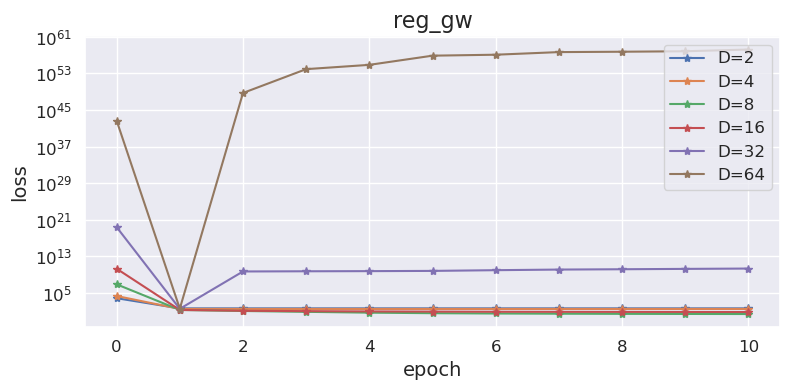

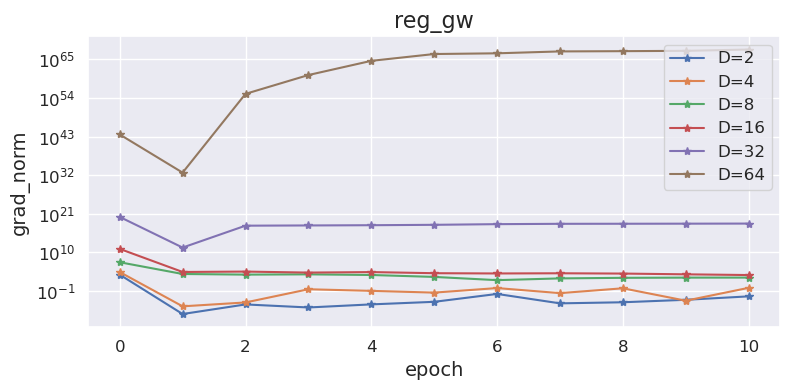

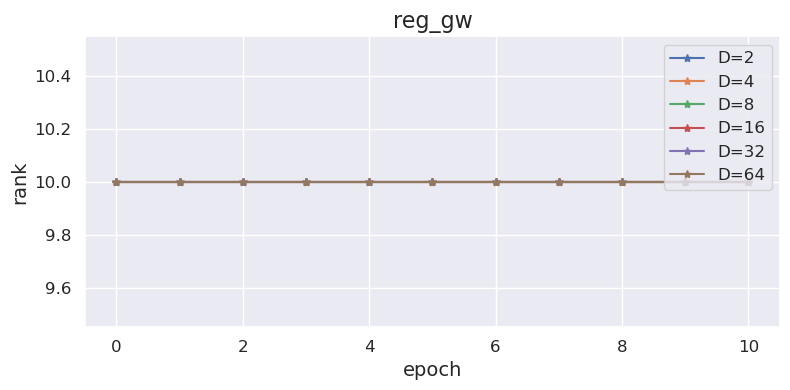

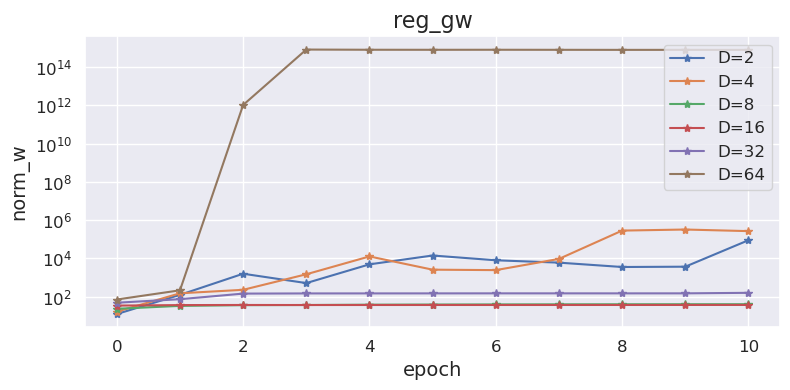

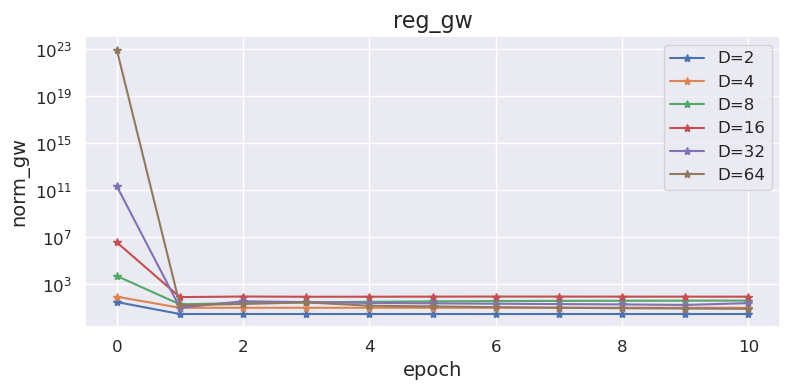

In [18]:
SAVE_DIR = Path(f'./artifacts/regularization/{setting}/{spec_str}')
create_dir_if_not_exists(SAVE_DIR)

for key in ['loss', 'grad_norm', 'rank', 'norm_w', 'norm_gw']:
    y_list = [v[::d_dim_list[i]] for i, v in enumerate(res_df[key])]
    plot_y_list(
        y_list=y_list, 
        leg_list=[f'D={d}' for d in d_dim_list], 
        xlabel='epoch',
        ylabel=f'{key}',
        title=f'{setting}',
        x_scale='linear',
        y_scale='log' if key != 'rank' else 'linear',
        save_path=SAVE_DIR / f'{key}.png',
    )

In [19]:
key = 'fwh_col_norm'

temp_dir = 'temp_gif_frames'
os.makedirs(temp_dir, exist_ok=True)
frame_paths = []
for ind in range(len(res_df[key])):
    frame_path = os.path.join(temp_dir, f'frame_{ind:03d}.png')
    y_list = np.array(res_df[key][ind]).T
    plot_y_list(
        y_list=y_list, 
        leg_list=[f'Col.N = {d}' for d in range(rank)], 
        xlabel=f'step: epoch x D',
        ylabel=f'{key}',
        title=f'{setting}; D={d_dim_list[ind]}',
        x_scale='linear',
        y_scale='log',
        save_path=frame_path,
        show_plot=False,
    )
    frame_paths.append(frame_path)
# Create GIF
#images = [imageio.imread(path) for path in frame_paths]
ref_image = Image.open(frame_paths[0])
ref_size = ref_image.size

# Open and resize all images
images = [Image.open(path).resize(ref_size) for path in frame_paths]
imageio.mimsave(SAVE_DIR / f'FW_Hadamard_Norm_Cols.gif', images, duration=2000, loop=0)
# Optionally: clean up frames
for path in frame_paths:
    os.remove(path)
os.rmdir(temp_dir)

In [20]:
key = 'A_eigenvalues'

temp_dir = 'temp_gif_frames'
os.makedirs(temp_dir, exist_ok=True)
frame_paths = []
for ind in range(len(res_df[key])):
    frame_path = os.path.join(temp_dir, f'frame_{ind:03d}.png')
    IR = m_order*rank
    ev_ind = [0, 1, 2, 3, IR-4, IR-3, IR-2, IR-1]
    y_list = np.array(res_df['A_eigenvalues'][ind]).real.T[ev_ind, :]
    plot_y_list(
        y_list=y_list, 
        leg_list=[f'EV = {d}' for d in ev_ind], 
        xlabel=f'step: epoch x D',
        ylabel=f'{key}',
        title=f'{setting}; D={d_dim_list[ind]}',
        x_scale='linear',
        y_scale='log',
        save_path=frame_path,
        show_plot=False,
    )
    frame_paths.append(frame_path)
# Create GIF
#images = [imageio.imread(path) for path in frame_paths]
ref_image = Image.open(frame_paths[0])
ref_size = ref_image.size

# Open and resize all images
images = [Image.open(path).resize(ref_size) for path in frame_paths]
imageio.mimsave(SAVE_DIR / f'A_eigenvalues.gif', images, duration=2000, loop=0)
# Optionally: clean up frames
for path in frame_paths:
    os.remove(path)
os.rmdir(temp_dir)

In [77]:
setting = 'no_reg'
if setting == 'no_reg':
    _ww_reg, _loss_f, _grad_w = False, l2_gb_loss, grad_w_jax
    gamma_w = 0
elif setting == 'reg_w':
    _ww_reg, _loss_f, _grad_w = False, l2_gb_loss, grad_w_jax
    gamma_w = 1e-3#1e-6, 1e-3
elif setting == 'reg_gw':
    _ww_reg, _loss_f, _grad_w = True, l2_greg, grad_w_greg_jax
    gamma_w = 1e-3#1e-6, 1e-3
n_samples, fmap_tuple, seed = 100, PPNFeature(), 1
beta_e, n_epoch = 1, 20
m_order, rank = 2, 10
d_dim = 64

x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
# Initialization:
w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_ten *= 1.0#2.0
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
w_vec_loc, tracker = als_cpd_reg(
    w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, 
    _loss_f, _grad_w, _ww_reg
)

KeyboardInterrupt: 

#### Visualization of the loss:

In [4]:
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

In [5]:
# Known setting:
n_samples, d_dim, m_order, rank = 100, 6, 2, 1
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 0e-6, 1.0
n_epoch = 100
init_gt = False
# Compute Data and Ground Truth:
x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
w_vec_true = ten3tovec(w_ten_true)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: 
    w_ten, _ = init_weights(
        m_order, rank=rank, 
        d_dim=x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
    w_ten *= 1.0
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape

def Jf(w_vec): return jacob_w_jax(x, kd, w_vec, fmap, *w_shape)
def f_vec(w_vec): return predict_score_vec(x, kd, w_vec, fmap, *w_shape)

w_vec_loc, tracker = als_cpd(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w_jax)

In [6]:
def tau(alpha, theta, theta_ast):
    return alpha * theta_ast + (1 - alpha) * theta

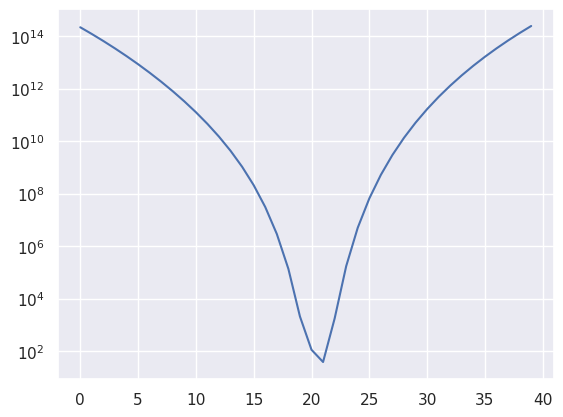

In [7]:
ls = []
for alpha in np.arange(-20, 20, 1):
    vv = tau(alpha, w_vec, w_vec_loc)
    ls.append(l2_gb_loss(vv, kd, x, y, fmap, gamma_w, beta_e, w_shape).item())

plt.plot(ls)
plt.yscale('log')


In [8]:
# Check Weights:
ind_x, ind_y = 0, 5
# Define ranges
lv, rv, n_points = -5, 5, 100
x_range, y_range = np.linspace(lv, rv, n_points), np.linspace(lv, rv, n_points)
X, Y = np.meshgrid(x_range, y_range)
z_values = np.zeros((len(y_range), len(x_range))) 

for i, _y in enumerate(y_range):
    for j, _x in enumerate(x_range):
        w_vec = w_vec.at[jnp.array([ind_x, ind_y])].set(jnp.array([_x, _y]))
        z_values[i, j] = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape).item()


min_val = np.min(z_values)
min_indices = np.argwhere(z_values == min_val)
min_points = [(x_range[j], y_range[i], z_values[i, j]) for i, j in min_indices]

local_minima = []

for i in range(1, len(y_range)-1):
    for j in range(1, len(x_range)-1):
        z = z_values[i, j]
        neighbors = [
            z_values[i-1, j-1], z_values[i-1, j], z_values[i-1, j+1],
            z_values[i, j-1],                   z_values[i, j+1],
            z_values[i+1, j-1], z_values[i+1, j], z_values[i+1, j+1],
        ]
        if z < min(neighbors):  # strict local minimum
            x = x_range[j]
            y = y_range[i]
            local_minima.append((x, y, z))


# Global minima trace
global_trace = go.Scatter3d(
    x=[x for x, y, z in min_points],
    y=[y for x, y, z in min_points],
    z=[z for x, y, z in min_points],
    mode='markers',
    marker=dict(size=7, color='red', symbol='diamond'),
    name='Global Minima'
)

# Local minima trace
local_trace = go.Scatter3d(
    x=[x for x, y, z in local_minima],
    y=[y for x, y, z in local_minima],
    z=[z for x, y, z in local_minima],
    mode='markers',
    marker=dict(size=5, color='blue', symbol='circle'),
    name='Local Minima'
)

In [9]:
fig = go.Figure()
# Surface
fig.add_trace(go.Surface(z=z_values, x=X, y=Y, colorscale='Turbo'))
# Global minima trace
fig.add_trace(global_trace)
# Local minima trace
fig.add_trace(local_trace)
fig.update_layout(title='Interactive 3D Surface', width=700, height=600, 
    scene=dict(xaxis_title='X Axis', yaxis_title='Y Axis', zaxis_title='Z Axis')
)
fig.show()

#### Looking for MAP estimate:

In [153]:
def stats(w_vec, kd, w_shape, w_vec_true, x, y, err, fmap, gamma_w, beta_e, f_vec, Jf):
    res_dict = dict()
    # Loss, Grad, Sol, Diff:
    w_ten = vec2ten3(w_vec, *w_shape)
    res_dict['J(v)'] = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape).item()
    res_dict['|dJ(v)|'] = norm_frob(ten3tovec(grad_cpd(w_ten, kd, x, y, fmap, gamma_w, beta_e))).item()
    res_dict['|v|'] = norm_frob(w_vec).item()
    try: res_dict['|v-v*|'] = norm_frob(w_vec - w_vec_true).item()
    except: pass
    res_dict['|f(v)-f(v*)|'] = norm_frob(f_vec(w_vec) - f_vec(w_vec_true)).item()
    res_dict['|f(v)-f(v*)-e|'] = norm_frob(f_vec(w_vec) - f_vec(w_vec_true) - err).item()
    res_dict['|Jf(v)^T[f(v)-f(v*)]|'] = norm_frob(Jf(w_vec).T.dot(f_vec(w_vec) - f_vec(w_vec_true))).item()
    res_dict['|Jf(v)^T[f(v)-f(v*)-e]|'] = norm_frob(Jf(w_vec).T.dot(f_vec(w_vec) - f_vec(w_vec_true) - err)).item()
    return res_dict

In [187]:
def als_cpd_new(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, tracker=None):
    D, I, R = w_shape
    w_ten = vec2ten3(w_vec, D, I, R)
    fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
    if tracker is not None: tracker.track(w_ten)
    for ep in range(n_epoch):
        for ind in range(D):
            # Preprocess:
            k, q = divmod(ind, kd) # q starts from zero -> for fmap
            wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
            fw_hadamard /= (fk_mtx.dot(wk) + 1e-14) # ZERO DIVISION?
            # Solve linear system:
            alpha = gamma_w / beta_e
            A, b = prepare_system(fk_mtx, fw_hadamard, y)
            A += alpha * jnp.eye(I*R)
            sol = np.linalg.solve(A, b)
            wk = jnp.array(sol.reshape(I, R, order='F')) # Fortran Ordering
            w_ten = w_ten.at[ind].set(wk)
            # Postprocess:
            fw_hadamard *= fk_mtx.dot(wk)
            check_nan(w_ten)
            if tracker is not None: tracker.track(w_ten)
    return ten3tovec(w_ten)

class Tracker():
    def __init__(self, fmap, x_train, y_train, kd, gamma_w, beta_e, grad_w):
        self.tracker = defaultdict(list)
        self.fmap = fmap
        self.x_train = x_train
        self.y_train = y_train
        self.kd = kd
        self.gamma_w = gamma_w
        self.beta_e = beta_e
        self.grad_w = grad_w
    
    def track(self, w_ten):
        train_loss_val = l2_gb_loss(
            ten3tovec(w_ten), self.kd, self.x_train, self.y_train, self.fmap, self.gamma_w, self.beta_e, w_ten.shape,
        ).item()
        loss_grad_norm = norm_frob(
            self.grad_w(ten3tovec(w_ten), self.kd, self.x_train, self.y_train, self.fmap, self.gamma_w, self.beta_e, w_ten.shape)
        ).item()
        update_results_dict(self.tracker, 
            train_loss_val=train_loss_val, 
            loss_grad_norm=loss_grad_norm,
            sol=ten3tovec(w_ten),
            gp=norm_frob(Jf(ten3tovec(w_ten)).T.dot(f_vec(ten3tovec(w_ten)) - self.y_train)).item()
        )

In [241]:
#SAVE_DIR = Path(f'./artifacts/local_behavior/map_search/')
#create_dir_if_not_exists(SAVE_DIR)
# Known setting:
n_samples, d_dim, m_order, rank = 100, 10, 5, 1
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 0e-6, 1.0
n_epoch = 100
init_gt = False
# Compute Data and Ground Truth:
x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
w_vec_true = ten3tovec(w_ten_true)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: 
    w_ten, _ = init_weights(
        m_order, rank=rank, 
        d_dim=x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
    w_ten *= 1.0
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape

def Jf(w_vec): return jacob_w_jax(x, kd, w_vec, fmap, *w_shape)
def f_vec(w_vec): return predict_score_vec(x, kd, w_vec, fmap, *w_shape)

def kr_cpd(w):
    d_dim = w.shape[0]
    krp = w[0, :, :].T
    for k in range(1, d_dim):
        krp = khatri_rao_row(w[k, :, :].T, krp)
    return krp

In [242]:
print('WITH NOISE')
tracker = Tracker(fmap, x, y, kd, gamma_w, beta_e, grad_w_jax)
w_vec_loc = als_cpd_new(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, tracker)
print('GT')
display(stats(w_vec_true, kd, w_ten_true.shape, w_vec_true, x, y, err, fmap, gamma_w, beta_e, f_vec, Jf))
print('ALS')
display(stats(w_vec_loc, kd, w_shape, w_vec_true, x, y, err, fmap, gamma_w, beta_e, f_vec, Jf))

WITH NOISE
GT


{'J(v)': 39.35859024251463,
 '|dJ(v)|': 14.404249215878929,
 '|v|': 6.858405008076315,
 '|v-v*|': 0.0,
 '|f(v)-f(v*)|': 0.0,
 '|f(v)-f(v*)-e|': 8.87227031176515,
 '|Jf(v)^T[f(v)-f(v*)]|': 0.0,
 '|Jf(v)^T[f(v)-f(v*)-e]|': 14.404249215879792}

ALS


{'J(v)': 13.23192071409192,
 '|dJ(v)|': 0.5795021881936026,
 '|v|': 121.71150474434799,
 '|v-v*|': 120.70871886017115,
 '|f(v)-f(v*)|': 7.210149781926037,
 '|f(v)-f(v*)-e|': 5.144301840695571,
 '|Jf(v)^T[f(v)-f(v*)]|': 234.5216964631339,
 '|Jf(v)^T[f(v)-f(v*)-e]|': 0.5795021881711158}

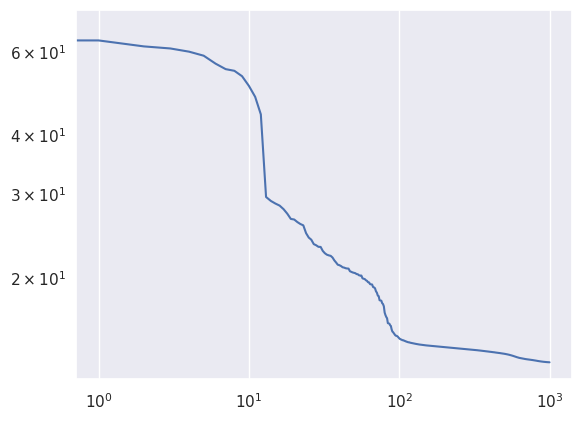

In [243]:
plt.plot(tracker.tracker['train_loss_val'])
plt.yscale('log')
plt.xscale('log')

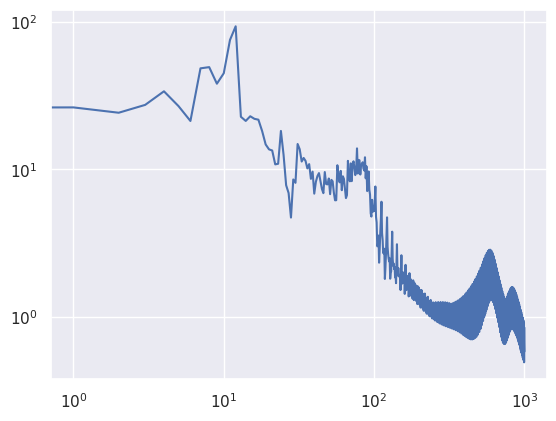

In [244]:
plt.plot(tracker.tracker['loss_grad_norm'])
plt.yscale('log')
plt.xscale('log')

In [ ]:
#krp_matrix = kr_cpd(vec2ten3(w_vec_loc, *w_shape)).T
#krp_matrix.shape, np.linalg.matrix_rank(krp_matrix)

#### Synthetic Setting (beta_e):
**Want to estimate beta_e:**

- Known: N, D, I, R, FMAP, Gamma_w; Init(w): Standard Normal / Ground Truth (GT);
- Optimizer: ALS
- Different Hessian estimators: Full / Gauss-Newton / Block;
- Low rank Covariance matrix: True / False; 

**Outcome**:
1. It is more stable to use Low-Rank Hessian - Covariance estimation
2. It is possible to find optimal beta_e with different Hessian estimation methods

In [7]:
def get_stats_1(mode, w_vec, kd, w_shape, w_cov, w_vec_true, x, y, fmap, gamma_w, beta_e):
    res_dict = dict()
    D, I, R = w_shape
    # Loss, Grad, Sol, Diff:
    w_ten = vec2ten3(w_vec, *w_shape)
    res_dict['mode'] = mode
    res_dict['loss'] = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape).item()
    res_dict['norm_grad'] = norm_frob(ten3tovec(grad_cpd(w_ten, kd, x, y, fmap, gamma_w, beta_e))).item()
    res_dict['norm_sol'] = norm_frob(w_vec).item()
    res_dict['norm_diff'] = (norm_frob(w_vec_true - w_vec) / norm_frob(w_vec_true)).item()
    # Covariance:
    res_dict[f'cov_symm'] = (norm_frob(w_cov - w_cov.T) < 1e-15).item() if w_cov is not None else None
    res_dict[f'cov_norm_off_bd'] = norm_frob(zero_diagonal_blocks(w_cov, I*R)).item() if w_cov is not None else None
    return res_dict

In [8]:
TRAIN = False
SAVE_DIR = Path(f'./artifacts/local_behavior/synthetic_setting_beta_e/')
create_dir_if_not_exists(SAVE_DIR)
# Known setting:
n_samples, fmap_tuple, seed = 100, PPNFeature(), 1
gamma_w, beta_e = 1e-6, 1
gamma_w_init, beta_e_init = gamma_w, None
n_epoch, n_epoch_g, beta_e_samples, low_rank_th = 50, 10, 10, 1e-3
init_gt = False
# Explore options:
params = dict(
    d_dim=[2, 4, 8],
    m_order=[2, 4, 8],
    rank=[2, 4, 8],
    hess_type=['full', 'gauss_newton', 'block'],
    low_rank=[False, True],
)
grid, param_names = full_grid(params)

# Start experiment:
if TRAIN:
    res_dict = defaultdict(list)
    for vals in tqdm(grid):
        d_dim, m_order, rank, hess_type, low_rank = vals
        # Compute Data and Ground Truth:
        x, y, _, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
        # Initialization:
        if init_gt: w_ten = jnp.copy(w_ten_true) 
        else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
        try:
            w_ten, kd, w_cov, w_cholesky, var_gamma_w, var_beta_e, _ = var_cpd_als(
                w_ten, kd, x, y, fmap, n_epoch, gamma_w_init, beta_e_init, 
                n_epoch_g, beta_e_samples, grad_w_jax, hess_type, low_rank, low_rank_th,
            )
            stats_dict = get_stats_1(
                '', ten3tovec(w_ten), kd, w_ten.shape, w_cov, ten3tovec(w_ten_true), x, y, fmap, var_gamma_w, var_beta_e
            )
            update_results_dict(
                res_dict, hess_type=hess_type, low_rank=low_rank, 
                loss=stats_dict['loss'], norm_grad=stats_dict['norm_grad'], norm_sol=stats_dict['norm_sol'], norm_diff=stats_dict['norm_diff'],
                cov_symm=stats_dict[f'cov_symm'], cov_norm_off_bd=stats_dict[f'cov_norm_off_bd'], beta_e=beta_e, var_beta_e=var_beta_e, 
                N=n_samples, D=d_dim, I=m_order, R=rank, gamma_w=gamma_w, fmap=fmap_tuple.name,
            )
        except:
            update_results_dict(
                res_dict, hess_type=hess_type, low_rank=low_rank, 
                loss=None, norm_grad=None, norm_sol=None, norm_diff=None,
                cov_symm=None, cov_norm_off_bd=None, beta_e=beta_e, var_beta_e=None, 
                N=n_samples, D=d_dim, I=m_order, R=rank, gamma_w=gamma_w, fmap=fmap_tuple.name,
            )
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(SAVE_DIR / 'beta_e_info.csv')
else:
    res_df = pd.read_csv(SAVE_DIR / 'beta_e_info.csv', index_col=0)

display(res_df)

,hess_type,low_rank,loss,norm_grad,norm_sol,norm_diff,cov_symm,cov_norm_off_bd,beta_e,var_beta_e,N,D,I,R,gamma_w,fmap
0,block,True,31.882756,0.000978,53.842711,9.819288,True,0.000000,1,1.335578,100,2,8,2,0.000001,ppnf
1,full,False,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,100,4,8,2,0.000001,ppnf
2,gauss_newton,False,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,100,4,8,4,0.000001,ppnf
3,block,True,30.377589,0.000046,7.666904,1.685530,True,0.000000,1,1.043231,100,4,2,4,0.000001,ppnf
4,block,True,0.002693,0.000006,6.675916,1.504068,True,0.000000,1,0.000077,100,2,4,4,0.000001,ppnf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,block,False,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,100,8,4,8,0.000001,ppnf
158,gauss_newton,False,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,100,8,8,8,0.000001,ppnf
159,full,True,44.184125,0.000021,9.237030,2.069815,True,0.637003,1,1.261794,100,4,2,2,0.000001,ppnf
160,gauss_newton,True,31.578881,0.000046,7.666998,1.685541,True,2.451984,1,1.084486,100,4,2,4,0.000001,ppnf


In [17]:
query_df(res_df, dict(low_rank=True, hess_type='full')).sort_values(by=['D', 'I', 'R'])

,hess_type,low_rank,loss,norm_grad,norm_sol,norm_diff,cov_symm,cov_norm_off_bd,beta_e,var_beta_e,N,D,I,R,gamma_w,fmap
57,full,True,47.956207,8.414863e-06,8.927314,2.310723,True,0.002601,1,1.231463,100,2,2,2,0.000001,ppnf
154,full,True,47.883722,7.384501e-06,4.577359,0.846245,True,0.012097,1,1.229603,100,2,2,4,0.000001,ppnf
28,full,True,47.822046,2.792491e-05,4.671601,1.344621,True,0.003387,1,1.228019,100,2,2,8,0.000001,ppnf
9,full,True,41.307658,4.603014e-05,10.480148,1.861972,True,2.818757,1,1.177868,100,2,4,2,0.000001,ppnf
24,full,True,40.292244,3.404525e-05,13.207442,2.430686,True,0.943143,1,1.154375,100,2,4,4,0.000001,ppnf
14,full,True,41.115024,6.784493e-05,6.286831,1.333212,True,0.886522,1,1.177950,100,2,4,8,0.000001,ppnf
94,full,True,5.753645,7.284979e-04,52.838432,9.647898,True,344.298712,1,0.240974,100,2,8,2,0.000001,ppnf
22,full,True,0.002111,3.561764e-06,17.884082,2.726919,True,596.712965,1,0.000080,100,2,8,4,0.000001,ppnf
7,full,True,0.000983,8.677338e-07,16.682014,2.015705,True,815.385654,1,0.000036,100,2,8,8,0.000001,ppnf
159,full,True,44.184125,2.109096e-05,9.237030,2.069815,True,0.637003,1,1.261794,100,4,2,2,0.000001,ppnf


In [19]:
query_df(res_df, dict(low_rank=True, hess_type='gauss_newton')).sort_values(by=['D', 'I', 'R'])

,hess_type,low_rank,loss,norm_grad,norm_sol,norm_diff,cov_symm,cov_norm_off_bd,beta_e,var_beta_e,N,D,I,R,gamma_w,fmap
71,gauss_newton,True,47.969262,8.414883e-06,8.927316,2.310723,True,0.002602,1,1.231799,100,2,2,2,0.000001,ppnf
126,gauss_newton,True,47.990086,7.369932e-06,4.577372,0.842139,True,0.012042,1,1.232334,100,2,2,4,0.000001,ppnf
8,gauss_newton,True,47.936122,2.802745e-05,4.672598,1.337436,True,0.003387,1,1.230948,100,2,2,8,0.000001,ppnf
152,gauss_newton,True,42.541554,4.586760e-05,10.480433,1.862049,True,2.138345,1,1.213052,100,2,4,2,0.000001,ppnf
40,gauss_newton,True,40.250668,3.412163e-05,13.207032,2.430621,True,0.946542,1,1.153184,100,2,4,4,0.000001,ppnf
66,gauss_newton,True,41.147707,6.769991e-05,6.286946,1.335525,True,0.883620,1,1.178886,100,2,4,8,0.000001,ppnf
35,gauss_newton,True,19.205326,9.193513e-04,53.594400,9.776791,True,144.169121,1,0.804493,100,2,8,2,0.000001,ppnf
33,gauss_newton,True,0.001636,3.479774e-06,15.699880,2.404145,True,650.986687,1,0.000061,100,2,8,4,0.000001,ppnf
17,gauss_newton,True,0.001293,7.412210e-07,18.514285,2.166402,True,794.385245,1,0.000050,100,2,8,8,0.000001,ppnf
47,gauss_newton,True,44.293994,2.111046e-05,9.237033,2.069816,True,0.478234,1,1.264931,100,4,2,2,0.000001,ppnf


GT: loss=4.8e+02; norm_grad=3.8e+02; norm_sol=2.4e+00; norm_diff=1.2e+00; 
FULL: symm? True; rank=8; max eigenval(real)=2.9e+02; min eigenval(real)=-1.6e+02; norm(off-block-diag)= 3.6e+02
GN: symm? True; rank=8; max eigenval(real)=1.8e+02; min eigenval(real)=1.0e-06; norm(off-block-diag)= 1.0e+02
BLOCK: symm? True; rank=8; max eigenval(real)=1.4e+02; min eigenval(real)=8.0e-01; norm(off-block-diag)= 0.0e+00
RMSE: GT=3.1e+00; GT=3.1e+00; (Full sample)=3.1e+00; (GN sample)=3.1e+00; (Block sample)=3.2e+00; 


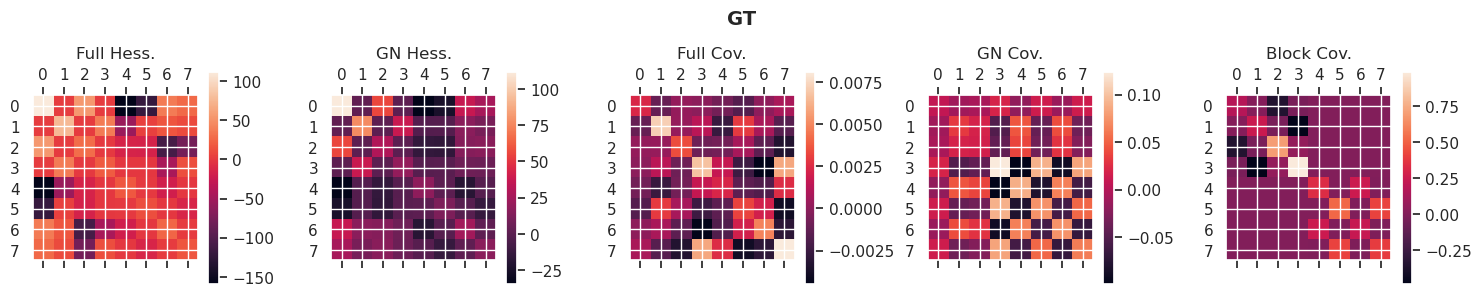

ALS: loss=3.9e+01; norm_grad=8.4e-06; norm_sol=8.9e+00; norm_diff=2.3e+00; 
FULL: symm? True; rank=8; max eigenval(real)=1.9e+03; min eigenval(real)=7.9e-07; norm(off-block-diag)= 5.8e+02
GN: symm? True; rank=8; max eigenval(real)=1.9e+03; min eigenval(real)=1.0e-06; norm(off-block-diag)= 5.8e+02
BLOCK: symm? True; rank=8; max eigenval(real)=1.8e+03; min eigenval(real)=8.0e-01; norm(off-block-diag)= 0.0e+00
RMSE: GT=8.9e-01; ALS=8.8e-01; (Full sample)=9.2e-01; (GN sample)=9.1e-01; (Block sample)=9.3e-01; 


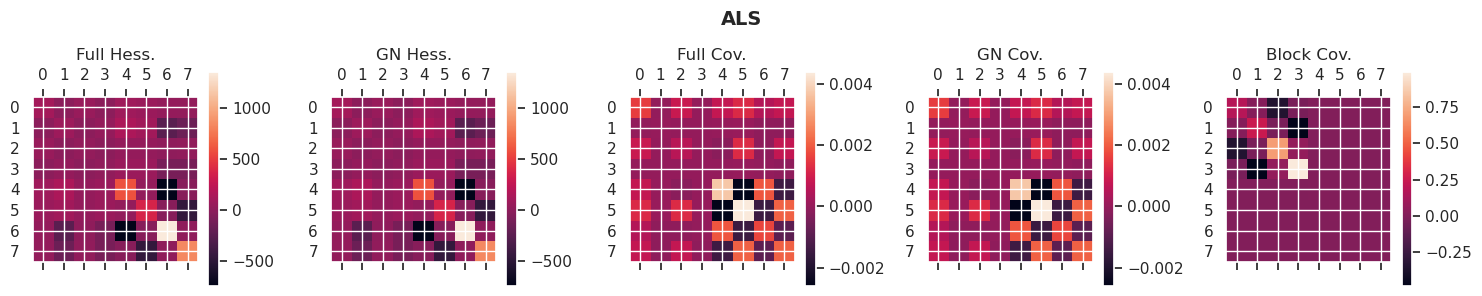

In [57]:
# Known setting:
n_samples, d_dim, m_order, rank = 100, 2, 2, 2
fmap_tuple, seed, n_epoch = PPNFeature(), 1, 100
gamma_w, beta_e = 1e-6, 1
init_gt = False
# Compute Data and Ground Truth:
x, y, _, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
# Find MAP estimate:
hess_type = 'full' # full / gauss_newton / block
low_rank, low_rank_th = True, 1e-3# True / False
gamma_w_init, beta_e_init = gamma_w, None

n_epoch_g, beta_e_samples = 10, 10
w_ten, kd, w_cov, w_cholesky, var_gamma_w, var_beta_e, tracker = var_cpd_als(
    w_ten, kd, x, y, fmap, n_epoch, gamma_w_init, beta_e_init, 
    n_epoch_g, beta_e_samples, grad_w_jax, hess_type, low_rank, low_rank_th,
)
res_dict = compute_behavior('GT', w_vec, kd, w_shape, ten3tovec(w_ten_true), x, y, fmap, gamma_w, beta_e, cov_lr=low_rank)
show_behavior(res_dict)
res_dict = compute_behavior('ALS', ten3tovec(w_ten), kd, w_shape, ten3tovec(w_ten_true), x, y, fmap, gamma_w, beta_e, cov_lr=low_rank)
show_behavior(res_dict)

#### Synthetic Setting (Weights):
**Want to estimate: (1) Local minima (MAP); (2) Curvature around it (Hess. -> Cov.); (3) Hint to update Beta_e (RMSE);**

- Known: N, D, I, R, FMAP, Gamma_w, Beta_e; Init(w): Standard Normal / Ground Truth (GT);
- Different optimizers: ALS / Adam / LBFGS / GN / LM; (1)
- Different Hessian estimators: Full / Gauss-Newton / Block; (2)
- Low rank Covariance matrix: True / False; (2)

In [ ]:
TRAIN = False
SAVE_DIR = Path(f'./artifacts/local_behavior/synthetic_setting_weights/')
create_dir_if_not_exists(SAVE_DIR)
# Known setting:
n_samples, d_dim, m_order, rank = 100, 2, 2, 2
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 1e-8, 1
init_gt = False
# Compute Data and Ground Truth:
x, y, _, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
# Prepare results dicts:
opt_list = ['GT', 'ALS', 'Adam', 'LBFGS', 'GN', 'LM']
hess_list = ['Full', 'GN', 'Block']
cov_lr_list = [True, False]
context_dict, hess_dict = defaultdict(list), defaultdict(list)
# Start experiment:
if TRAIN:
    for opt in opt_list:
        # Get solution (1):
        if opt == 'GT': w_vec_loc = ten3tovec(w_ten_true)
        else: w_vec_loc = cpd_solution(opt, w_vec, kd, w_shape, x, y, fmap, gamma_w, beta_e, grad_w_jax)
        # Evaluate and find Hess/Cov (2):
        for cov_lr in cov_lr_list:
            res_dict = compute_behavior(opt, w_vec_loc, kd, w_shape, ten3tovec(w_ten_true), x, y, fmap, gamma_w, beta_e, cov_lr)
            for name_hess in hess_list:
                # This is about Beta_e (3):
                rmse_sample, _n_samp = None, None
                if res_dict[f'{name_hess}_success']: 
                    rmse_sample = res_dict[f'rmse_{opt}_sample_{name_hess}']
                    _n_samp = res_dict[f'rmse_{opt}_{name_hess}_n_samples']
                update_results_dict(
                    hess_dict, opt=opt, hess=name_hess, cov_lr=cov_lr, symm=res_dict[f'{name_hess}_symm'], rank=res_dict[f'{name_hess}_rank'],
                    max_eigen=res_dict[f'{name_hess}_max_eigen'], min_eigen=res_dict[f'{name_hess}_min_eigen'],
                    norm_off_bd=res_dict[f'{name_hess}_norm_off_bd'], chol_success=res_dict[f'{name_hess}_success'], 
                    rmse_GT=res_dict[f'rmse_GT'], rmse_sol=res_dict[f'rmse_{opt}'], rmse_sample=rmse_sample, n_samp=_n_samp
                )
                hess_spec_name = f'{opt} {"LR Cov." if cov_lr else ""}'
                save_matrix_behavior(res_dict, hess_spec_name, SAVE_DIR / (hess_spec_name + '.png'), show_plot=False, dpi=200)
        # I assume 'res_dict' values below do not depend on 'cov_lr' !!!
        update_results_dict(
            context_dict, opt=opt, loss=res_dict['loss'], 
            norm_grad=res_dict['norm_grad'], norm_sol=res_dict['norm_sol'], rel_norm_diff=res_dict['norm_diff'],
            N=n_samples, D=d_dim, I=m_order, R=rank, fmap=fmap_tuple.name, gamma_w=gamma_w, beta_e=beta_e, init_GT=init_gt,
        )
    context_df, hess_df = pd.DataFrame(context_dict), pd.DataFrame(hess_dict)
    context_df.to_csv(SAVE_DIR / 'context_info.csv')
    hess_df.to_csv(SAVE_DIR / 'hess_info.csv')
else:
    context_df, hess_df = pd.read_csv(SAVE_DIR / 'context_info.csv', index_col=0), pd.read_csv(SAVE_DIR / 'hess_info.csv', index_col=0)

display(context_df)
display(hess_df)

,opt,loss,norm_grad,norm_sol,rel_norm_diff,N,D,I,R,fmap,gamma_w,beta_e,init_GT
0,GT,39.358590,1.004496e+01,6.126919,0.000000,100,10,2,2,ppnf,1.000000e-08,1,False
1,ALS,22.620638,3.060060e-07,9.778717,1.921623,100,10,2,2,ppnf,1.000000e-08,1,False
2,Adam,27.350620,6.501527e+00,7.253041,1.619583,100,10,2,2,ppnf,1.000000e-08,1,False
3,LBFGS,22.722472,4.963308e-07,7.136007,1.675290,100,10,2,2,ppnf,1.000000e-08,1,False
4,GN,25.344306,1.582649e+03,28.941533,4.892166,100,10,2,2,ppnf,1.000000e-08,1,False
5,LM,22.146370,1.536807e-07,8.094363,1.761018,100,10,2,2,ppnf,1.000000e-08,1,False


,opt,hess,cov_lr,symm,rank,max_eigen,min_eigen,norm_off_bd,chol_success,rmse_GT,rmse_sol,rmse_sample,n_samp
0,GT,Full,True,True,40,5.313531e+01,-1.140965e+01,66.647693,True,0.887227,0.887227,3.150504e+02,10.0
1,GT,GN,True,True,40,3.367715e+01,9.999997e-09,33.085748,True,0.887227,0.887227,8.607246e+02,10.0
2,GT,Block,True,True,40,2.535672e+01,5.148939e-02,0.000000,True,0.887227,0.887227,3.242726e+01,10.0
3,GT,Full,False,True,40,5.313531e+01,-1.140965e+01,66.647693,False,0.887227,0.887227,NaN,NaN
4,GT,GN,False,True,40,3.367715e+01,9.999997e-09,33.085748,True,0.887227,0.887227,4.316992e+37,10.0
5,GT,Block,False,True,40,2.535672e+01,5.148939e-02,0.000000,True,0.887227,0.887227,3.974316e+02,10.0
6,ALS,Full,True,True,40,2.198078e+03,1.078016e-08,514.187707,True,0.887227,0.672616,9.759399e-01,10.0
7,ALS,GN,True,True,40,2.197428e+03,9.999815e-09,509.813627,True,0.887227,0.672616,8.183993e-01,10.0
8,ALS,Block,True,True,40,2.151114e+03,6.784200e-01,0.000000,True,0.887227,0.672616,9.271384e-01,10.0
9,ALS,Full,False,True,40,2.198078e+03,1.078016e-08,514.187707,True,0.887227,0.672616,5.986437e+34,10.0


#### Show Behavior:

GT: loss=3.9e+01; norm_grad=1.1e+01; norm_sol=3.8e+00; norm_diff=0.0e+00; 
FULL: symm? True; rank=8; max eigenval(real)=3.7e+02; min eigenval(real)=-2.8e+00; norm(off-block-diag)= 2.7e+02
GN: symm? True; rank=8; max eigenval(real)=3.7e+02; min eigenval(real)=1.0e-11; norm(off-block-diag)= 2.7e+02
BLOCK: symm? True; rank=8; max eigenval(real)=2.7e+02; min eigenval(real)=2.2e+01; norm(off-block-diag)= 0.0e+00
RMSE: GT=8.9e-01; GT=8.9e-01; (Full sample)=1.2e+00; (GN sample)=9.1e-01; (Block sample)=9.4e-01; 


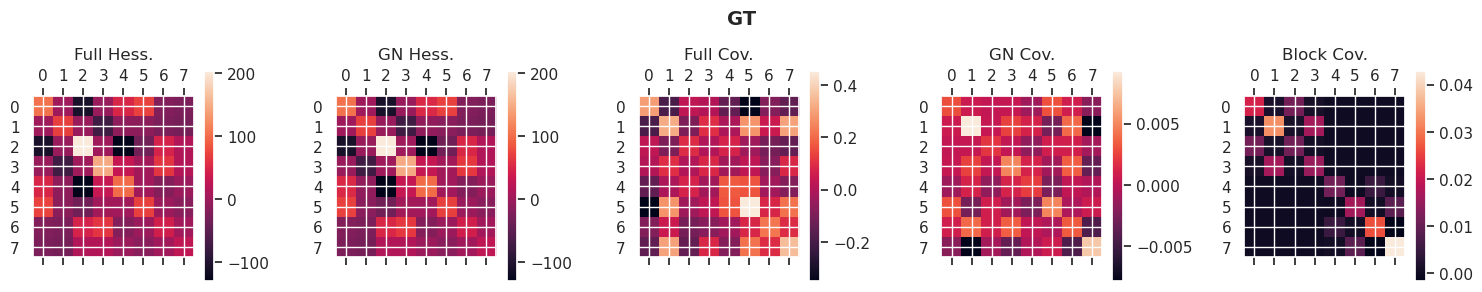

ALS: loss=3.9e+01; norm_grad=1.4e-09; norm_sol=8.9e+00; norm_diff=2.3e+00; 
FULL: symm? True; rank=8; max eigenval(real)=1.9e+03; min eigenval(real)=-2.1e-10; norm(off-block-diag)= 5.8e+02
GN: symm? True; rank=8; max eigenval(real)=1.9e+03; min eigenval(real)=9.8e-12; norm(off-block-diag)= 5.8e+02
BLOCK: symm? True; rank=8; max eigenval(real)=1.8e+03; min eigenval(real)=8.0e-01; norm(off-block-diag)= 0.0e+00
RMSE: GT=8.9e-01; ALS=8.8e-01; (Full sample)=9.1e-01; (GN sample)=9.0e-01; (Block sample)=9.4e-01; 


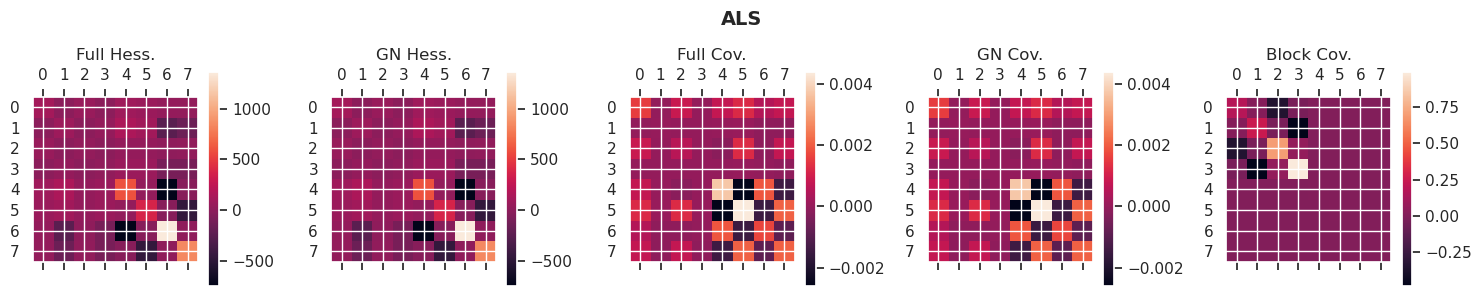

In [209]:
n_samples, d_dim, m_order, rank = 100, 2, 2, 2
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 1e-11, 1
opt_name = 'ALS' # ALS / Adam / LBFGS / GN / LM
init_gt = False
cov_lr = True

# Compute Data and Ground Truth:
x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
y_check = y
# Initialisation:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
# Solve:
w_vec = cpd_solution(opt_name, w_vec, kd, w_shape, x, y_check, fmap, gamma_w, beta_e, grad_w_jax)
w_ten = vec2ten3(w_vec, *w_ten.shape)
# Ground Truth solution:
mode = 'GT'
res_dict_gt = compute_behavior(mode, ten3tovec(w_ten_true), kd, w_shape, ten3tovec(w_ten_true), x, y, fmap, gamma_w, beta_e, cov_lr)
show_behavior(res_dict_gt)
# Solution:
mode = opt_name
res_dict_sol = compute_behavior(mode, w_vec, kd, w_shape, ten3tovec(w_ten_true), x, y, fmap, gamma_w, beta_e, cov_lr)
show_behavior(res_dict_sol)

#### ALS Behavior (No noise, open setting):

In [ ]:
TRAIN = True
SAVE_DIR = Path(f'./artifacts/local_behavior/synthetic_setting_no_noise/')
create_dir_if_not_exists(SAVE_DIR)
# Known setting:
n_samples, d_dim, m_order, rank = 100, 3, 2, 2
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 1e-8, 1
init_gt = False
# Compute Data and Ground Truth:
x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
# Prepare results dicts:
opt_list = ['ALS']#['GT', 'ALS', 'Adam', 'LBFGS', 'GN', 'LM']
hess_list = ['Full', 'GN', 'Block']
cov_lr_list = [True, False]
context_dict, hess_dict = defaultdict(list), defaultdict(list)
# Start experiment:
if TRAIN:
    for opt in opt_list:
        # Get solution (1):
        if opt == 'GT': w_vec_loc = ten3tovec(w_ten_true)
        else: w_vec_loc = None #cpd_solution(opt, w_vec, kd, w_shape, x, y_true, fmap, gamma_w, beta_e, grad_w_jax)
        w_vec_loc, tracker = als_cpd(w_vec, kd, w_shape, x, y, fmap, 1000, gamma_w, beta_e, grad_w_jax)
        # Evaluate and find Hess/Cov (2):
        for cov_lr in cov_lr_list:
            res_dict = compute_behavior(opt, w_vec_loc, kd, w_shape, ten3tovec(w_ten_true), x, y_true, fmap, gamma_w, beta_e, cov_lr)
            for name_hess in hess_list:
                # This is about Beta_e (3):
                rmse_sample, _n_samp = None, None
                if res_dict[f'{name_hess}_success']: 
                    rmse_sample = res_dict[f'rmse_{opt}_sample_{name_hess}']
                    _n_samp = res_dict[f'rmse_{opt}_{name_hess}_n_samples']
                update_results_dict(
                    hess_dict, opt=opt, hess=name_hess, cov_lr=cov_lr, symm=res_dict[f'{name_hess}_symm'], rank=res_dict[f'{name_hess}_rank'],
                    max_eigen=res_dict[f'{name_hess}_max_eigen'], min_eigen=res_dict[f'{name_hess}_min_eigen'],
                    norm_off_bd=res_dict[f'{name_hess}_norm_off_bd'], chol_success=res_dict[f'{name_hess}_success'], 
                    rmse_GT=res_dict[f'rmse_GT'], rmse_sol=res_dict[f'rmse_{opt}'], rmse_sample=rmse_sample, n_samp=_n_samp
                )
                hess_spec_name = f'{opt} {"LR Cov." if cov_lr else ""}'
                save_matrix_behavior(res_dict, hess_spec_name, SAVE_DIR / (hess_spec_name + '.png'), show_plot=False, dpi=200)
        # I assume 'res_dict' values below do not depend on 'cov_lr' !!!
        update_results_dict(
            context_dict, opt=opt, loss=res_dict['loss'], 
            norm_grad=res_dict['norm_grad'], norm_sol=res_dict['norm_sol'], rel_norm_diff=res_dict['norm_diff'],
            N=n_samples, D=d_dim, I=m_order, R=rank, fmap=fmap_tuple.name, gamma_w=gamma_w, beta_e=beta_e, init_GT=init_gt,
        )
    context_df, hess_df = pd.DataFrame(context_dict), pd.DataFrame(hess_dict)
    context_df.to_csv(SAVE_DIR / 'context_info.csv')
    hess_df.to_csv(SAVE_DIR / 'hess_info.csv')
else:
    context_df, hess_df = pd.read_csv(SAVE_DIR / 'context_info.csv', index_col=0), pd.read_csv(SAVE_DIR / 'hess_info.csv', index_col=0)

display(context_df)
display(hess_df)

,opt,loss,norm_grad,norm_sol,rel_norm_diff,N,D,I,R,fmap,gamma_w,beta_e,init_GT
0,ALS,2.340627,103.437118,11.269827,2.975849,100,3,2,2,ppnf,1.000000e-08,1,False


,opt,hess,cov_lr,symm,rank,max_eigen,min_eigen,norm_off_bd,chol_success,rmse_GT,rmse_sol,rmse_sample,n_samp
0,ALS,Full,True,True,12,8048.152783,-2.648081e+01,6230.555997,True,0.0,0.216362,4.285755e-01,10.0
1,ALS,GN,True,False,12,8052.991505,9.999160e-09,6233.400573,True,0.0,0.216362,2.843301e+00,10.0
2,ALS,Block,True,True,12,3965.429317,1.574608e+00,0.000000,True,0.0,0.216362,3.850432e-01,10.0
3,ALS,Full,False,True,12,8048.152783,-2.648081e+01,6230.555997,False,0.0,0.216362,NaN,NaN
4,ALS,GN,False,False,12,8052.991505,9.999160e-09,6233.400573,True,0.0,0.216362,1.905901e+11,10.0
5,ALS,Block,False,True,12,3965.429317,1.574608e+00,0.000000,True,0.0,0.216362,3.811037e-01,10.0


### Test Autograd and Manual functions:

In [ ]:
n_samples = 100
fmap_tuple = PPNFeature()
seed, beta_e = 1, 1

options_dict = dict(
    d_dim=[2, 4, 8],
    m_order=[2, 4, 8],
    rank=[2, 4, 8],
    gamma_w=[0, 1e-8]
)
grid, param_names = full_grid(options_dict)

res_dict = defaultdict(list)
for opts in tqdm(grid):
    d_dim, m_order, rank, gamma_w = opts

    x, y, y_true, fmap, w_ten_true, kd = generate_model_data(
        n_samples, d_dim, m_order, rank, fmap_tuple, std_err=1/np.sqrt(beta_e), seed=seed
    )
    w_vec_true, w_true_shape = ten3tovec(w_ten_true), w_ten_true.shape

    w_grad_manual = ten3tovec(grad_cpd(w_ten_true, kd, x, y_true, fmap, gamma_w, beta_e))
    w_grad_jax = grad_w_jax(w_vec_true, kd, x, y_true, fmap, gamma_w, beta_e, w_true_shape)

    w_jacob_manual = jacob_cpd(w_ten_true, kd, x, fmap)
    w_jacob_jax = jacob_w_jax(x, kd, w_vec_true, fmap, *w_true_shape)

    w_hess_manual = hess_full(w_ten_true, kd, x, y_true, fmap, gamma_w, beta_e, mode='full')
    w_hess_jax = hess_w_jax(w_vec_true, kd, x, y_true, fmap, gamma_w, beta_e, w_true_shape)

    w_hess_gn = beta_e*w_jacob_manual.T.dot(w_jacob_manual) 
    w_hess_gn += gamma_w*jnp.eye(*w_hess_gn.shape)

    norm_grad_diff = norm_frob(w_grad_manual - w_grad_jax)
    norm_grad = norm_frob(w_grad_manual)
    norm_jacob_diff = norm_frob(w_jacob_manual- w_jacob_jax)
    norm_full_hess_diff = norm_frob(w_hess_manual- w_hess_jax)
    norm_full_hess_symm = norm_frob(w_hess_manual - w_hess_manual.T)
    rank_full_hess = np.linalg.matrix_rank(w_hess_manual)
    norm_gn_hess_symm = norm_frob(w_hess_gn - w_hess_gn.T)
    rank_gn_hess = np.linalg.matrix_rank(w_hess_gn)
    try:
        np.linalg.cholesky(w_hess_manual)
        full_hess_chol_success = True
    except Exception as e:
        full_hess_chol_success = False
    try:
        np.linalg.cholesky(w_hess_gn)
        gn_hess_chol_success = True
    except Exception as e:
        gn_hess_chol_success = False

    update_results_dict(res_dict, 
        d_dim=d_dim, m_order=m_order, rank=rank, n_params=d_dim*m_order*rank,
        rank_fhess=rank_full_hess, rank_gn_hess=rank_gn_hess, gamma_w=gamma_w, 
        fhess_chol_success=full_hess_chol_success, gn_hess_chol_success=gn_hess_chol_success,
        norm_gd_diff=norm_grad_diff, norm_gd=norm_grad, norm_jn_diff=norm_jacob_diff,
        norm_fhess_diff=norm_full_hess_diff, norm_fhess_symm=norm_full_hess_symm,
        norm_gn_hess_symm=norm_gn_hess_symm, 
    )

  0%|          | 0/54 [00:00<?, ?it/s]

100%|██████████| 54/54 [00:43<00:00,  1.23it/s]


In [19]:
df = pd.DataFrame(res_dict)
float_cols = ['gamma_w', 'norm_gd_diff', 'norm_gd', 'norm_jn_diff', 'norm_fhess_diff']
df[float_cols] = df[float_cols].applymap(lambda x: f'{x:.1e}')
display(df.sort_values(by='gamma_w'))

,d_dim,m_order,rank,n_params,rank_fhess,rank_gn_hess,gamma_w,fhess_chol_success,gn_hess_chol_success,norm_gd_diff,norm_gd,norm_jn_diff,norm_fhess_diff,norm_fhess_symm,norm_gn_hess_symm
53,2,4,4,32,16,16,0.0e+00,False,False,1.8e-12,1.8e-12,6.9e-12,9.5e-14,0.0,0.0
34,2,8,8,128,64,64,0.0e+00,False,False,3.2e-12,3.2e-12,3.4e-11,7.1e-14,0.0,0.0
33,2,2,8,32,4,4,0.0e+00,False,False,2.7e-12,2.7e-12,4.5e-10,2.9e-13,0.0,0.0
39,8,8,4,256,100,100,0.0e+00,False,False,4.5e-12,4.5e-12,9.1e-12,1.0e-13,0.0,0.0
30,4,4,8,128,100,100,0.0e+00,False,False,5.7e-12,5.7e-12,2.0e-11,2.3e-13,0.0,0.0
28,8,8,2,128,100,100,0.0e+00,False,False,9.0e-14,9.0e-14,1.1e-12,2.8e-15,0.0,0.0
27,2,8,4,64,48,48,0.0e+00,False,False,2.0e-12,2.0e-12,1.5e-11,3.0e-14,0.0,0.0
44,4,2,2,16,10,10,0.0e+00,False,False,6.9e-12,6.9e-12,5.5e-12,2.0e-13,0.0,0.0
23,2,8,2,32,28,28,0.0e+00,False,False,7.8e-13,7.8e-13,2.8e-12,3.2e-14,0.0,0.0
22,8,2,8,128,72,72,0.0e+00,False,False,4.9e-12,4.9e-12,1.5e-09,2.6e-13,0.0,0.0


### Order ALS Update?

In [27]:
def als_cpd_regular(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w):
    D, I, R = w_shape
    w_ten = vec2ten3(w_vec, D, I, R)
    loss_all = []
    for ep in range(n_epoch):
        for ind in range(w_ten.shape[0]):
            fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
            wk = step(ind, fw_hadamard, w_ten, kd, I, R, x, y, fmap, gamma_w, beta_e)
            w_ten = w_ten.at[ind].set(wk)
            check_nan(w_ten)
            loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape).item()
            loss_all.append((ind, loss_val, norm_frob(grad_w(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape)).item()))
    return ten3tovec(w_ten), loss_all

def als_cpd_brute_force(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w):
    D, I, R = w_shape
    w_ten = vec2ten3(w_vec, D, I, R)
    loss_all = []
    for ep in range(n_epoch):
        for _ in range(D):
            loss_ep = []
            for ind in range(D):
                fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
                wk = step(ind, fw_hadamard, w_ten, kd, I, R, x, y, fmap, gamma_w, beta_e)
                w_ten_local = w_ten.at[ind].set(wk)
                loss_ep.append(l2_gb_loss(ten3tovec(w_ten_local), kd, x, y, fmap, gamma_w, beta_e, w_shape).item())
                check_nan(w_ten_local)
            ind_min = np.argmin(loss_ep)
            fw_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
            wk = step(ind_min, fw_hadamard, w_ten, kd, I, R, x, y, fmap, gamma_w, beta_e)
            w_ten = w_ten.at[ind_min].set(wk)
            check_nan(w_ten)
            loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape).item()
            loss_all.append((ind_min, loss_val, norm_frob(grad_w(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_shape)).item()))
    return ten3tovec(w_ten), loss_all

def step(ind, fw_hadamard, w_ten, kd, I, R, x, y, fmap, gamma_w, beta_e):
    k, q = divmod(ind, kd) # q starts from zero -> for fmap
    wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
    den = (fk_mtx.dot(wk) + 1e-14)
    fw_hadamard /= den 
    # Solve linear system:
    alpha = gamma_w / beta_e
    A, b = prepare_system(fk_mtx, fw_hadamard, y)
    A += alpha * jnp.eye(I*R)
    sol = np.linalg.solve(A, b)
    return jnp.array(sol.reshape(I, R, order='F')) # Fortran Ordering

In [84]:
# Known setting:
n_samples, d_dim, m_order, rank = 100, 10, 2, 1
fmap_tuple, seed = PPNFeature(), 1
gamma_w, beta_e = 1e-8, 1.0
init_gt = False
# Compute Data and Ground Truth:
x, y, y_true, err, fmap, w_ten_true, kd = generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, 1/np.sqrt(beta_e), seed=seed)
w_vec_true = ten3tovec(w_ten_true)
# Initialization:
if init_gt: w_ten = jnp.copy(w_ten_true) 
else: w_ten, _ = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=13, dtype=w_ten_true.dtype)
w_vec, w_shape = ten3tovec(w_ten), w_ten.shape

n_epoch = 30
w_vec_regular, tracker_regular = als_cpd_regular(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w_jax)
w_vec_brute_force, tracker_brute_force = als_cpd_brute_force(w_vec, kd, w_shape, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w_jax)

In [85]:
tracker_regular[-6:]

[(4, 33.74606595489295, 0.03959633047042483),
 (5, 33.746065427922524, 0.039461358655292295),
 (6, 33.74606347270385, 0.036284956203357845),
 (7, 33.746044132498795, 0.016331128452724115),
 (8, 33.74604410379769, 0.016448150856064454),
 (9, 33.74604334819195, 0.013088276245391928)]

In [86]:
tracker_brute_force[-6:]

[(2, 26.705404432716016, 1.399720422072941e-06),
 (2, 26.705404432716016, 1.399720427233061e-06),
 (2, 26.705404432716016, 1.399720422072941e-06),
 (2, 26.705404432716016, 1.399720427233061e-06),
 (2, 26.705404432716016, 1.399720422072941e-06),
 (2, 26.705404432716016, 1.399720427233061e-06)]